# Disk-to-dumbbell empirical McCann interpolation

This notebook illustrates the finite-sample quadratic optimal map from a uniform disk to a connected non-convex target made of two disks joined by a thin rectangle.  It computes an equal-weight empirical OT map
\[
T_N = \arg\min_{\sigma\in\mathfrak S_N} \frac1N\sum_i \|x_i-y_{\sigma(i)}\|^2
\]
between two farthest-point samples, then displays the McCann interpolation
\[
\alpha_t^N = ((1-t)\mathrm{Id}+tT_N)_\#\alpha_0^N,
\qquad t\in[0,1].
\]
Colors are inherited from the horizontal coordinate of the initial disk, which helps track how material regions of the disk are rearranged into the final connected two-disk shape.

In [2]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb
from scipy.optimize import linear_sum_assignment
from scipy.stats import qmc

sys.path.append(str(Path.cwd() / "notebooks-figures"))
from figure_style import BLUE, RED, VIOLET, figure_dir, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
rng = np.random.default_rng(2048)
OUT = figure_dir("monge-caffarelli-nonconvex-map")
THUMB = Path("notebooks-figures/thumbnails/monge-caffarelli-nonconvex-map.png")
ARXIV_OUT = Path("arxiv/figures")
ARXIV_OUT.mkdir(parents=True, exist_ok=True)


## Sampling and assignment

Both domains are sampled by farthest-point subsampling from large quasi-random candidate sets.  This keeps the displayed particles evenly spaced without introducing a grid.  The target is the union of two disks and a narrow rectangular bridge, so it is connected but non-convex.  Since the two empirical measures have equal weights, the quadratic OT problem reduces to a linear assignment.

In [4]:
N_POINTS = 5200
DISK_RADIUS = 0.78
TARGET_RADIUS = 0.54
TARGET_OFFSET = 0.88
BRIDGE_HALF_HEIGHT = 0.145
BRIDGE_HALF_LENGTH = TARGET_OFFSET


def farthest_point_sample(candidates, n, *, first_index=None):
    """Greedy farthest-point subsampling from a fixed candidate cloud."""
    candidates = np.asarray(candidates, dtype=np.float64)
    if first_index is None:
        first_index = int(np.argmin(np.sum(candidates**2, axis=1)))
    selected = np.empty(n, dtype=np.int64)
    selected[0] = first_index
    dist2 = np.sum((candidates - candidates[first_index]) ** 2, axis=1)
    for k in range(1, n):
        idx = int(np.argmax(dist2))
        selected[k] = idx
        new_dist2 = np.sum((candidates - candidates[idx]) ** 2, axis=1)
        dist2 = np.minimum(dist2, new_dist2)
    return candidates[selected]


def disk_candidates(power=18, radius=DISK_RADIUS, seed=11):
    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sampler.random_base2(power)
    theta = 2 * np.pi * u[:, 0]
    rad = radius * np.sqrt(u[:, 1])
    return np.column_stack([rad * np.cos(theta), rad * np.sin(theta)])


def in_dumbbell(points):
    x, y = points[:, 0], points[:, 1]
    left = (x + TARGET_OFFSET) ** 2 + y**2 <= TARGET_RADIUS**2
    right = (x - TARGET_OFFSET) ** 2 + y**2 <= TARGET_RADIUS**2
    bridge = (np.abs(x) <= BRIDGE_HALF_LENGTH) & (np.abs(y) <= BRIDGE_HALF_HEIGHT)
    return left | right | bridge


def dumbbell_candidates(power=18, seed=17):
    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sampler.random_base2(power)
    xmin, xmax = -TARGET_OFFSET - TARGET_RADIUS, TARGET_OFFSET + TARGET_RADIUS
    ymin, ymax = -TARGET_RADIUS, TARGET_RADIUS
    pts = np.column_stack([xmin + (xmax - xmin) * u[:, 0], ymin + (ymax - ymin) * u[:, 1]])
    return pts[in_dumbbell(pts)]


X_candidates = disk_candidates()
Y_candidates = dumbbell_candidates()
X = farthest_point_sample(X_candidates, N_POINTS)
Y = farthest_point_sample(Y_candidates, N_POINTS)

# Exact equal-weight OT assignment for the squared Euclidean cost.
X32 = X.astype(np.float32)
Y32 = Y.astype(np.float32)
C = np.sum(X32**2, axis=1)[:, None] + np.sum(Y32**2, axis=1)[None, :] - 2 * X32 @ Y32.T
C = np.maximum(C, 0).astype(np.float32)
row_ind, col_ind = linear_sum_assignment(C)
assert np.array_equal(row_ind, np.arange(N_POINTS))
T = Y[col_ind]
mean_cost = float(C[row_ind, col_ind].mean())
print(f"N={N_POINTS}, candidate disk={len(X_candidates)}, target={len(Y_candidates)}, mean squared cost={mean_cost:.5f}")


## Splatted McCann interpolation

The same color is attached to each material point throughout the interpolation.  It is a function of the original horizontal coordinate in the disk: red on the left, blue on the right, and violet in the middle.  The panels are exported without embedded titles; the manuscript supplies the time labels.

In [6]:
TIMES = [0.0, 0.25, 0.5, 0.75, 1.0]
PANEL_NAMES = ["mccann-t000.pdf", "mccann-t025.pdf", "mccann-t050.pdf", "mccann-t075.pdf", "mccann-t100.pdf"]
POINT_SIZE = 6.4
POINT_ALPHA = 0.31


def interpolate_rgb(t, color0=RED, color1=BLUE):
    a = np.array(to_rgb(color0))
    b = np.array(to_rgb(color1))
    return (1 - t) * a + t * b


# Color is indexed by the source disk x-coordinate.
color_level = (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min())
point_colors = np.array([interpolate_rgb(s) for s in color_level])
draw_order = rng.permutation(N_POINTS)

all_points = np.vstack([X, T])
xmin, ymin = all_points.min(axis=0)
xmax, ymax = all_points.max(axis=0)
xspan = xmax - xmin
yspan = ymax - ymin
panel_ratio = 1.82 / 1.04
pad = 0.035
xspan *= 1 + 2 * pad
yspan *= 1 + 2 * pad
if xspan / yspan > panel_ratio:
    yspan = xspan / panel_ratio
else:
    xspan = yspan * panel_ratio
cx = 0.5 * (xmin + xmax)
cy = 0.5 * (ymin + ymax)
XLIM = (cx - xspan / 2, cx + xspan / 2)
YLIM = (cy - yspan / 2, cy + yspan / 2)


def draw_cloud(ax, Z):
    Zp = Z[draw_order]
    Cp = point_colors[draw_order]
    ax.scatter(
        Zp[:, 0],
        Zp[:, 1],
        s=POINT_SIZE,
        c=Cp,
        alpha=POINT_ALPHA,
        linewidths=0,
        marker="o",
        rasterized=True,
    )
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_aspect("equal")
    remove_axes(ax)


for t, name in zip(TIMES, PANEL_NAMES):
    Z = (1 - t) * X + t * T
    fig, ax = plt.subplots(figsize=(1.82, 1.04))
    draw_cloud(ax, Z)
    save_pdf(fig, OUT / name, pad_inches=0.006)
    shutil.copyfile(OUT / name, ARXIV_OUT / f"monge-caffarelli-nonconvex-map--{name}")
    plt.close(fig)

# Compact thumbnail for the searchable gallery and README.
fig, axes = plt.subplots(1, len(TIMES), figsize=(9.1, 1.18))
for ax, t in zip(axes, TIMES):
    draw_cloud(ax, (1 - t) * X + t * T)
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0, wspace=0.018)
THUMB.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(THUMB, dpi=190, bbox_inches="tight", pad_inches=0.01)
plt.close(fig)
print("Saved", len(PANEL_NAMES), "PDF panels and", THUMB)


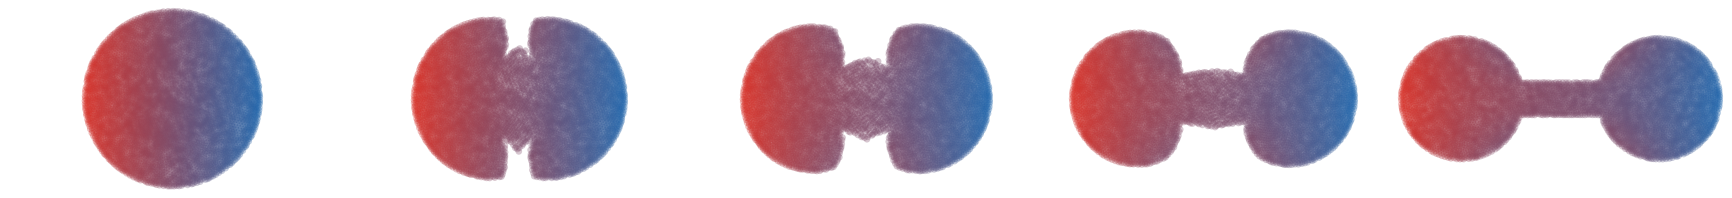

In [7]:
from IPython.display import Image, display

display(Image(filename=str(THUMB)))
